In [2]:
from sapphire import visualization
# import importlib
# importlib.reload(visualization)

(<Figure size 1320x360 with 3 Axes>,
 array([<Axes: xlabel='$\\log M_{\\rm vir}/M_{\\odot}$ (z=0)', ylabel='$\\log M_*/M_{\\rm vir}$ (z=0)'>,
        <Axes: xlabel='$\\log M_*/M_{\\odot}$ (z=0)', ylabel='$\\log M_{\\rm ISM}/M_*$ (z=0)'>,
        <Axes: xlabel='$\\log M_*/M_{\\odot}$ (z=0)', ylabel='$\\log Z_*/Z_{\\odot}$ (z=0)'>],
       dtype=object))

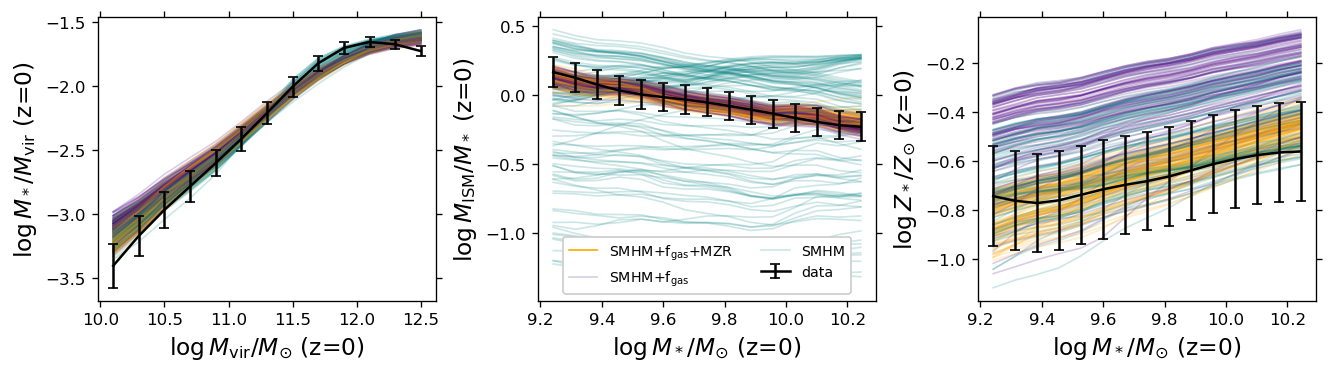

In [3]:
visualization.numpyro_plots.posterior_predictive_checks('/mnt/ceph/users/vpandya/sapphire_outputs/',
                                  'numpyro_mix_chain%s_%s.npz',None)

(<Figure size 1320x360 with 3 Axes>,
 array([<Axes: xlabel='$\\log M_{\\rm vir}/M_{\\odot}$ (z=0)', ylabel='$\\log M_*/M_{\\rm vir}$ (z=0)'>,
        <Axes: xlabel='$\\log M_*/M_{\\odot}$ (z=0)', ylabel='$\\log M_{\\rm ISM}/M_*$ (z=0)'>,
        <Axes: xlabel='$\\log M_*/M_{\\odot}$ (z=0)', ylabel='$\\log Z_*/Z_{\\odot}$ (z=0)'>],
       dtype=object))

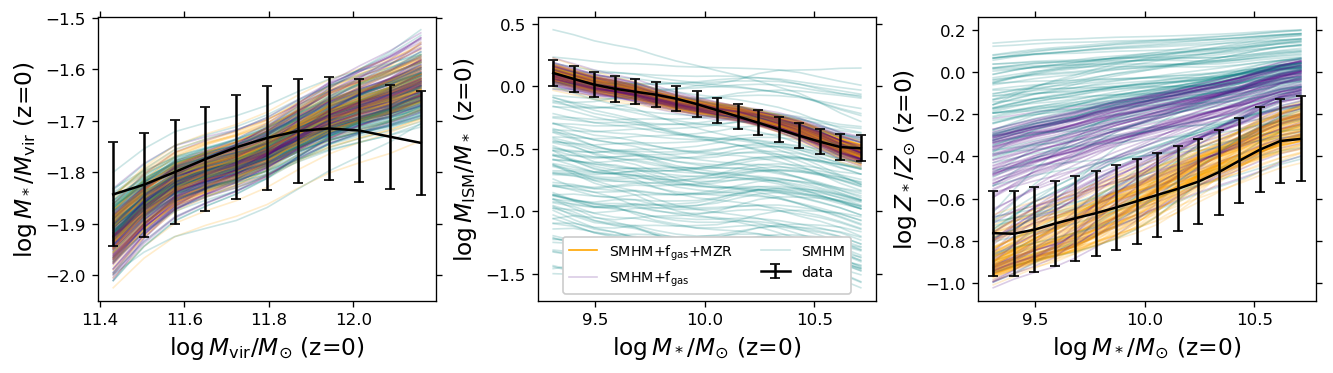

In [20]:
visualization.numpyro_plots.posterior_predictive_checks('/mnt/ceph/users/vpandya/sapphire_outputs/',
                                  'numpyro_manga_chain%s_%s_fixsmhm.npz',None)

In [5]:
### read in obs data
# WARNING: sapphire needs to be refactored since loading this first screws up num_cpus for XLA 
from sapphire.utils import read_obs
obs_manga = read_obs.read_manga({'obs_path':'/mnt/ceph/users/vpandya/sapphire/data/obs/'})
obs_lit = read_obs.read_literature({'obs_path':'/mnt/ceph/users/vpandya/sapphire/data/obs/'}) # behroozi SMHM
obs_mix = read_obs.read_mix({'obs_path':'/mnt/ceph/users/vpandya/sapphire/data/obs/'}) # behroozi SMHM

Text(0, 0.5, '$\\log Z_*/Z_{\\odot}$ (z=0)')

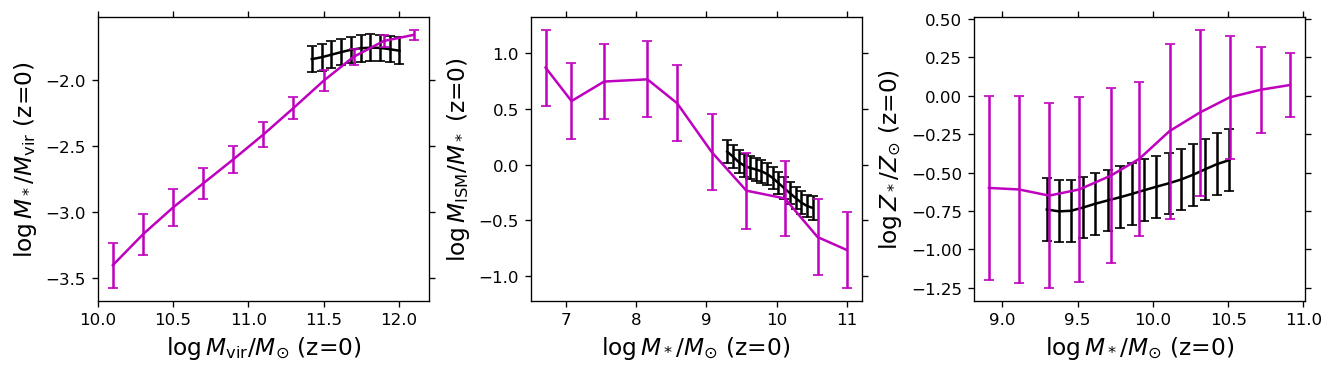

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(nrows=1,ncols=3,figsize=(11,3),constrained_layout=True)
ax_smhm, ax_fgas, ax_mzr = axes

##### first the data/constraints
ax_smhm.errorbar(obs_manga[0],obs_manga[2],yerr=obs_manga[3],fmt='-',color='k',capsize=3,zorder=np.inf)
ax_smhm.errorbar(obs_lit[0],obs_lit[2],yerr=obs_lit[3],fmt='-',color='m',capsize=3,zorder=np.inf)

    
# axes[0].set_xscale('log')
ax_smhm.set_xlabel(r'$\log M_{\rm vir}/M_{\odot}$ (z=0)',fontsize=14)
ax_smhm.set_ylabel(r'$\log M_*/M_{\rm vir}$ (z=0)',fontsize=14)

ax_fgas.errorbar(obs_manga[4],obs_manga[6],yerr=obs_manga[7],fmt='-',capsize=3,zorder=np.inf,color='k',label='data')
ax_fgas.errorbar(obs_lit[4],obs_lit[6],yerr=obs_lit[7],fmt='-',capsize=3,zorder=np.inf,color='m',label='data')

# plt.xscale('log')
ax_fgas.set_xlabel(r'$\log M_*/M_{\odot}$ (z=0)',fontsize=14)
ax_fgas.set_ylabel(r'$\log M_{\rm ISM}/M_*$ (z=0)',fontsize=14)

ax_mzr.errorbar(obs_manga[8],obs_manga[10],yerr=obs_manga[11],fmt='-',capsize=3,zorder=np.inf,color='k')
ax_mzr.errorbar(obs_lit[8],obs_lit[10],yerr=obs_lit[11],fmt='-',capsize=3,zorder=np.inf,color='m')

ax_mzr.set_xlabel(r'$\log M_*/M_{\odot}$ (z=0)',fontsize=14)
ax_mzr.set_ylabel(r'$\log Z_*/Z_{\odot}$ (z=0)',fontsize=14)

(<Figure size 1320x360 with 3 Axes>,
 array([<Axes: xlabel='$\\log M_{\\rm vir}/M_{\\odot}$ (z=0)', ylabel='$\\log M_*/M_{\\rm vir}$ (z=0)'>,
        <Axes: xlabel='$\\log M_*/M_{\\odot}$ (z=0)', ylabel='$\\log M_{\\rm ISM}/M_*$ (z=0)'>,
        <Axes: xlabel='$\\log M_*/M_{\\odot}$ (z=0)', ylabel='$\\log Z_*/Z_{\\odot}$ (z=0)'>],
       dtype=object))

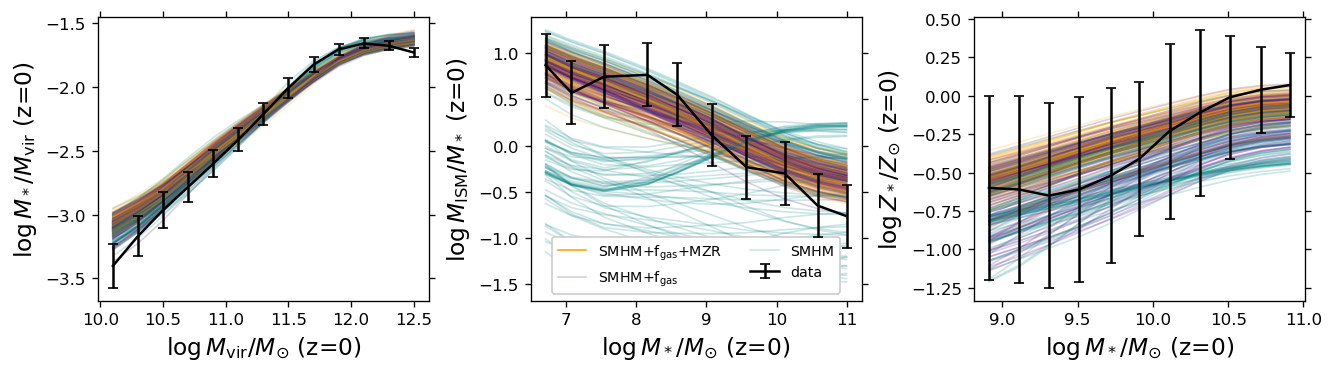

In [23]:
###  old literature (unrealistically large MZR and fgas errorbars)
visualization.numpyro_plots.posterior_predictive_checks('/mnt/ceph/users/vpandya/sapphire_outputs/',
                                  'numpyro_lit_chain%s_%s.npz',obs_lit)

In [24]:
obs_manga[0], obs_lit[0]

(Array([11.43128929, 11.50409867, 11.57690805, 11.64971742, 11.7225268 ,
        11.79533618, 11.86814556, 11.94095494, 12.01376431, 12.08657369,
        12.15938307], dtype=float64),
 Array([10.1, 10.3, 10.5, 10.7, 10.9, 11.1, 11.3, 11.5, 11.7, 11.9, 12.1,
        12.3, 12.5], dtype=float64))

# testing manually single run

In [8]:
%matplotlib inline 
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import Planck15
from astropy.table import Table
from astropy import constants as const
from astropy import units as u
from glob import glob
import h5py 
from timeit import default_timer as timer
import multiprocess

import os, sys
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=50"
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false' # for GPU 

from jax import config
config.update("jax_enable_x64", True)
import jax.numpy as jnp
from jax._src.third_party.scipy.interpolate import RegularGridInterpolator as jax_RegularGridInterpolator
from jax import jit, grad, vmap, pmap, debug, jvp, vjp, jacrev, jacfwd, make_jaxpr, hessian, value_and_grad
from jax_cosmo.scipy.interpolate import InterpolatedUnivariateSpline

from scipy.interpolate import InterpolatedUnivariateSpline as scipy_InterpolatedUnivariateSpline
from scipy.ndimage import gaussian_filter1d

from jax.experimental.ode import odeint
from jax.lax import fori_loop, while_loop
from jax.scipy.integrate import trapezoid

from diffrax import diffeqsolve, ODETerm, PIDController, SaveAt, Kvaerno3, Bosh3, Dopri5, Tsit5, DirectAdjoint, RecursiveCheckpointAdjoint, BacksolveAdjoint

from diffrax import backward_hermite_coefficients, CubicInterpolation

from functools import partial

from jax.random import PRNGKey, key

import numpyro
import numpyro.distributions as dist
from numpyro.examples.datasets import LYNXHARE, load_dataset
from numpyro.infer import MCMC, NUTS, Predictive, AIES, ESS

from jax.experimental import mesh_utils
from jax.experimental.shard_map import shard_map
from jax.sharding import Mesh, PartitionSpec, NamedSharding

import optax

import arviz as az
import seaborn as sns
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from chainconsumer import Chain, ChainConsumer, make_sample, PlotConfig, Truth, ChainConfig
from matplotlib.colors import Normalize
import matplotlib.gridspec as gridspec

import jax
jax.config.update('num

print(jax.devices())

plt.rcParams['figure.dpi'] = 120
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.top'] = True

[CpuDevice(id=0)]


In [11]:
output_path = '/mnt/ceph/users/vpandya/sapphire_outputs'
basestr = 'numpyro_mix_chain%s_%s.npz'

In [14]:
### read in obs data
# WARNING: sapphire needs to be refactored since loading this first screws up num_cpus for XLA 
from sapphire.utils import read_obs
obs_manga = read_obs.read_manga({'obs_path':'/mnt/ceph/users/vpandya/sapphire/data/obs/'})
obs_lit = read_obs.read_literature({'obs_path':'/mnt/ceph/users/vpandya/sapphire/data/obs/'}) # behroozi SMHM
obs_mix = read_obs.read_mix({'obs_path':'/mnt/ceph/users/vpandya/sapphire/data/obs/'}) # behroozi SMHM

obs_stats = obs_mix

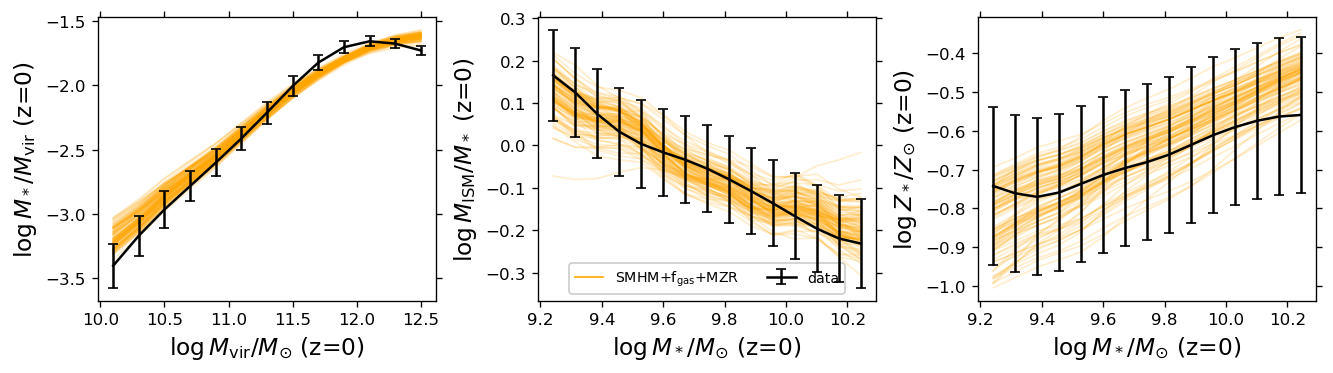

In [15]:
### TO DO: generalize this for future more complicated flags or other constraint dtypes
def get_predictives(flag,obs_stats):

    chain_preds_smhm, chain_preds_fgas, chain_preds_mzr = [],[],[]

    # TO DO: generalize depending on actual # of chains
    for cnum in range(0,4):
    
        # TO DO: generalize this beyond numpyro_manga_chain%s_%s.npz
        fname = os.path.join(output_path,'outputs',basestr%(cnum,flag))
        npz_nuts = jnp.load(fname,allow_pickle=True)

        # just take the random posterior realizations without errorbars 
        pred_avg_smhm = npz_nuts['samples'].item()['pred_avg_smhm']
        pred_avg_fgas = npz_nuts['samples'].item()['pred_avg_fgas']
        pred_avg_mzr = npz_nuts['samples'].item()['pred_avg_mzr']
    
        chain_preds_smhm.append(pred_avg_smhm)
        chain_preds_fgas.append(pred_avg_fgas)
        chain_preds_mzr.append(pred_avg_mzr)

    ### if obs_stats is None, use the (already-open) last npz file to extract obs_stats
    # TO DO: generalize this for arbitrary summary statistics, and perhaps move to another function outside
    if obs_stats == None:
        # consider saving as dict['obs_stats'] = tuple to prevent npz error, and make it easier to load here/elsewhere
        obs_stats = (npz_nuts['obs_x0_smhm'],npz_nuts['obs_bw_smhm'],npz_nuts['obs_avg_smhm'],npz_nuts['obs_err_smhm'],
                     npz_nuts['obs_x0_fgas'],npz_nuts['obs_bw_fgas'],npz_nuts['obs_avg_fgas'],npz_nuts['obs_err_fgas'],
                     npz_nuts['obs_x0_mzr'],npz_nuts['obs_bw_mzr'],npz_nuts['obs_avg_mzr'],npz_nuts['obs_err_mzr'])

    # if we didn't use obs_stats from file, then the input one will be returned
    return jnp.vstack(chain_preds_smhm), jnp.vstack(chain_preds_fgas), jnp.vstack(chain_preds_mzr), obs_stats

preds_smhm_111, preds_fgas_111, preds_mzr_111, obs_stats = get_predictives('111',obs_stats)
# preds_smhm_110, preds_fgas_110, preds_mzr_110, obs_stats = get_predictives('110',obs_stats)
# preds_smhm_100, preds_fgas_100, preds_mzr_100, obs_stats = get_predictives('100',obs_stats)

##### PLOT
### TO DO: generalize this for arbitrary predictives 
color_obs = 'k'
color_111, color_110, color_100 = 'orange', 'indigo', 'teal'

fig, axes = plt.subplots(nrows=1,ncols=3,figsize=(11,3),constrained_layout=True)
ax_smhm, ax_fgas, ax_mzr = axes

##### first the data/constraints
ax_smhm.errorbar(obs_stats[0],obs_stats[2],yerr=obs_stats[3],
             fmt='-',color=color_obs,capsize=3,zorder=np.inf)

    
# axes[0].set_xscale('log')
ax_smhm.set_xlabel(r'$\log M_{\rm vir}/M_{\odot}$ (z=0)',fontsize=14)
ax_smhm.set_ylabel(r'$\log M_*/M_{\rm vir}$ (z=0)',fontsize=14)

ax_fgas.errorbar(obs_stats[4],obs_stats[6],yerr=obs_stats[7],
                 fmt='-',capsize=3,zorder=np.inf,color=color_obs,label='data')

# plt.xscale('log')
ax_fgas.set_xlabel(r'$\log M_*/M_{\odot}$ (z=0)',fontsize=14)
ax_fgas.set_ylabel(r'$\log M_{\rm ISM}/M_*$ (z=0)',fontsize=14)

ax_mzr.errorbar(obs_stats[8],obs_stats[10],yerr=obs_stats[11],
                 fmt='-',capsize=3,zorder=np.inf,color=color_obs)

ax_mzr.set_xlabel(r'$\log M_*/M_{\odot}$ (z=0)',fontsize=14)
ax_mzr.set_ylabel(r'$\log Z_*/Z_{\odot}$ (z=0)',fontsize=14)

##### plot random draws from posterior
drawnums = jax.random.choice(key(1),jnp.arange(preds_smhm_111.shape[0]),(100,),replace=False)
# drawnums = np.arange(100)

for inum,ival in enumerate(drawnums):
    
    ax_smhm.plot(obs_stats[0],preds_smhm_111[ival],'-',color=color_111,alpha=0.2,lw=1)
    # ax_smhm.plot(obs_stats[0],preds_smhm_110[ival],'-',color=color_110,alpha=0.2,lw=1)
    # ax_smhm.plot(obs_stats[0],preds_smhm_100[ival],'-',color=color_100,alpha=0.2,lw=1)

    ax_fgas.plot(obs_stats[4],preds_fgas_111[ival],'-',color=color_111,alpha=0.2,lw=1,
                 label=r'SMHM+f$_{\rm gas}$+MZR' if inum==0 else '__none__')
    # ax_fgas.plot(obs_stats[4],preds_fgas_110[ival],'-',color=color_110,alpha=0.2,lw=1,label=r'SMHM+f$_{\rm gas}$' if inum==0 else '__none__')
    # ax_fgas.plot(obs_stats[4],preds_fgas_100[ival],'-',color=color_100,alpha=0.2,lw=1,label=r'SMHM' if inum==0 else '__none__')

    ax_mzr.plot(obs_stats[8],preds_mzr_111[ival],'-',color=color_111,alpha=0.2,lw=1)
    # ax_mzr.plot(obs_stats[8],preds_mzr_110[ival],'-',color=color_110,alpha=0.2,lw=1)
    # ax_mzr.plot(obs_stats[8],preds_mzr_100[ival],'-',color=color_100,alpha=0.2,lw=1)

leg = ax_fgas.legend(fontsize=8.5,fancybox=True,framealpha=1,ncol=2,loc='lower center')
leg.get_lines()[0].set_alpha(1.0)



# manually test selection effects

In [1]:
%matplotlib inline 
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import Planck15
from astropy.table import Table
from astropy import constants as const
from astropy import units as u
from glob import glob
import h5py 
from timeit import default_timer as timer
import multiprocess

import jax
jax.config.update("jax_enable_x64", True) # required to accurately solve and take gradients through our diffeqs 
jax.config.update('jax_num_cpu_devices', 50) # newer jax versions don't need the XLA environment flag above

print(jax.devices())

import os, sys
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=50"
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false' # for GPU 

import jax.numpy as jnp
from jax._src.third_party.scipy.interpolate import RegularGridInterpolator as jax_RegularGridInterpolator
from jax import jit, grad, vmap, pmap, debug, jvp, vjp, jacrev, jacfwd, make_jaxpr, hessian, value_and_grad
from jax_cosmo.scipy.interpolate import InterpolatedUnivariateSpline

from scipy.interpolate import InterpolatedUnivariateSpline as scipy_InterpolatedUnivariateSpline
from scipy.ndimage import gaussian_filter1d

from jax.experimental.ode import odeint
from jax.lax import fori_loop, while_loop
from jax.scipy.integrate import trapezoid

from diffrax import diffeqsolve, ODETerm, PIDController, SaveAt, Kvaerno3, Bosh3, Dopri5, Tsit5, DirectAdjoint, RecursiveCheckpointAdjoint, BacksolveAdjoint

from diffrax import backward_hermite_coefficients, CubicInterpolation

from functools import partial

from jax.random import PRNGKey, key

import numpyro
import numpyro.distributions as dist
from numpyro.examples.datasets import LYNXHARE, load_dataset
from numpyro.infer import MCMC, NUTS, Predictive, AIES, ESS

from jax.experimental import mesh_utils
from jax.experimental.shard_map import shard_map
from jax.sharding import Mesh, PartitionSpec, NamedSharding

import optax

import arviz as az
import seaborn as sns
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from chainconsumer import Chain, ChainConsumer, make_sample, PlotConfig, Truth, ChainConfig
from matplotlib.colors import Normalize
import matplotlib.gridspec as gridspec

plt.rcParams['figure.dpi'] = 120
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.top'] = True

[CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7), CpuDevice(id=8), CpuDevice(id=9), CpuDevice(id=10), CpuDevice(id=11), CpuDevice(id=12), CpuDevice(id=13), CpuDevice(id=14), CpuDevice(id=15), CpuDevice(id=16), CpuDevice(id=17), CpuDevice(id=18), CpuDevice(id=19), CpuDevice(id=20), CpuDevice(id=21), CpuDevice(id=22), CpuDevice(id=23), CpuDevice(id=24), CpuDevice(id=25), CpuDevice(id=26), CpuDevice(id=27), CpuDevice(id=28), CpuDevice(id=29), CpuDevice(id=30), CpuDevice(id=31), CpuDevice(id=32), CpuDevice(id=33), CpuDevice(id=34), CpuDevice(id=35), CpuDevice(id=36), CpuDevice(id=37), CpuDevice(id=38), CpuDevice(id=39), CpuDevice(id=40), CpuDevice(id=41), CpuDevice(id=42), CpuDevice(id=43), CpuDevice(id=44), CpuDevice(id=45), CpuDevice(id=46), CpuDevice(id=47), CpuDevice(id=48), CpuDevice(id=49)]


/mnt/home/vpandya/miniconda3/envs/japphire/lib/python3.12/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound
/tmp/ipykernel_535452/2678942479.py:49: DeprecationWarning: jax.experimental.shard_map is deprecated in v0.8.0. Used jax.shard_map instead.
  from jax.experimental.shard_map import shard_map


In [3]:
output_path = '/mnt/ceph/users/vpandya/sapphire_outputs'
basestr = 'numpyro_mix_chain%s_%s.npz'

In [4]:
##### load posterior predictive samples

params_free = ["A_M","alpha0_M","A_E","alpha0_E","A_SF","alpha0_SF","A_Z","alpha0_Z"]

def get_samples(flag):
    ### loop over and store posterior samples from all 4 chains    
    # samples dataframes indexed by int for chain_num for Gelman-Rubin statistic 
    chain_samples = {}
    
    # TO DO: generalize depending on actual # of chains
    for cnum in range(0,4):
    
        # TO DO: generalize this beyond numpyro_manga_chain%s_%s.npz
        fname = os.path.join(output_path,'outputs',basestr%(cnum,flag))
        npz_nuts = jnp.load(fname,allow_pickle=True)
    
        samples_dict = {k: npz_nuts['samples'].item()[k] for k in params_free}
        samples_df = pd.DataFrame(samples_dict)
        chain_samples[cnum] = samples_df
    
    # combine the different chains' posterior samples
    samples_df = pd.concat(chain_samples.values(), ignore_index=True)  

    return samples_df

samples_df111 = get_samples('111')

In [5]:
samples_df111

,A_M,alpha0_M,A_E,alpha0_E,A_SF,alpha0_SF,A_Z,alpha0_Z
0,-0.016506,-1.959059,-0.411679,-0.730971,0.917991,-1.888016,-0.175731,-0.821896
1,-0.112169,-1.802395,-0.388320,-1.199302,0.912711,-1.935205,-0.269336,-0.669986
2,0.433002,-1.591351,-0.451445,-0.544943,0.969070,-1.924861,-0.333725,-1.197213
3,0.250167,-1.503487,-0.425566,-0.846645,0.978537,-1.851708,-0.353885,-1.558105
4,0.178729,-0.714824,-0.431321,-0.689713,0.958575,-1.991705,-0.346524,-1.041428
...,...,...,...,...,...,...,...,...
7995,0.183898,-1.466003,-0.426867,-0.928864,0.994899,-1.999152,-0.564255,-0.213405
7996,0.120455,-1.602182,-0.421403,-0.841336,0.988412,-1.999199,-0.416269,-0.212889
7997,0.085993,-1.946485,-0.439410,-0.653623,0.920399,-1.998775,-0.046165,-1.102059
7998,0.261369,-0.620120,-0.387455,-0.631502,0.984625,-1.998325,-0.040235,-1.632799


In [6]:
samples_df111.loc[0].to_dict()

{'A_M': -0.016506325435842406,
 'alpha0_M': -1.9590587135512518,
 'A_E': -0.4116792393802313,
 'alpha0_E': -0.7309713841959695,
 'A_SF': 0.9179913684483831,
 'alpha0_SF': -1.8880159044578386,
 'A_Z': -0.17573069739250924,
 'alpha0_Z': -0.8218959830342174}

In [8]:
# easiest to re-read in the config that determined ODE model setup
# this should've been same regardless of inference constraints
from sapphire.utils import read_config
config = read_config.get({'path_config':'/mnt/ceph/users/vpandya/sapphire/scripts/config.yaml'})

### now modify for single run
config['runtype'] = 'single'

# overwrite default params to a random row from posterior samples
config['params_fixed_astro'] = {**config['params_fixed_astro'],**samples_df111.loc[0].to_dict()}

config['params_fixed_astro']

{'alpha_n': -1.5,
 'alpha_T': 0.0,
 'f_recycle': 0.4,
 'yZ': 0.02,
 'A_M': -0.016506325435842406,
 'alpha0_M': -1.9590587135512518,
 'A_E': -0.4116792393802313,
 'alpha0_E': -0.7309713841959695,
 'A_SF': 0.9179913684483831,
 'alpha0_SF': -1.8880159044578386,
 'A_Z': -0.17573069739250924,
 'alpha0_Z': -0.8218959830342174,
 'alphaz_M': 0.0,
 'beta_M': 0.0,
 'alphaz_E': 0.0,
 'beta_E': 0.0,
 'alphaz_SF': 0.0,
 'beta_SF': -0.7,
 'alphaz_Z': 0.0,
 'beta_Z': 0.0}

In [9]:
import os
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=%s"%config['num_cpus']

import sapphire

In [10]:
out_sapphire = sapphire.run(config)
sol = out_sapphire[0]

reading /mnt/ceph/users/vpandya/sapphire/scripts/config.yaml

your full sapphire config:

{   'Nbatch': 1000,
    'chain_num': 0,
    'coolfunc': 'sd93',
    'flag_fgas': 1,
    'flag_mzr': 1,
    'flag_smhm': 1,
    'inference_config': {   'Nadam': 3,
                            'adam_logL': 'numpyro',
                            'engine': 'nuts',
                            'fit_mock': False,
                            'fit_obs': True,
                            'num_samples': 2000,
                            'num_warmup': 2000,
                            'random_mock': True,
                            'write_output': True},
    'model': 'pandya23',
    'num_cpus': 50,
    'obs_err_fgas': 0.0,
    'obs_err_mzr': 0.0,
    'obs_err_smhm': 0.0,
    'obs_name': 'lit',
    'obs_path': '/mnt/ceph/users/vpandya/sapphire/data/obs/',
    'output_path': '/mnt/ceph/users/vpandya/sapphire_outputs/',
    'output_prefix': 'numpyro_{obs_name}_chain{chain_num}',
    'output_suffix': '{flag_smhm

In [13]:
from sapphire.summaries import gaussian_kernel_regression as gkr

### read in obs data
# WARNING: sapphire needs to be refactored since loading this first screws up num_cpus for XLA 
from sapphire.utils import read_obs
obs_manga = read_obs.read_manga({'obs_path':'/mnt/ceph/users/vpandya/sapphire/data/obs/'})
obs_lit = read_obs.read_literature({'obs_path':'/mnt/ceph/users/vpandya/sapphire/data/obs/'}) # behroozi SMHM
obs_mix = read_obs.read_mix({'obs_path':'/mnt/ceph/users/vpandya/sapphire/data/obs/'}) # behroozi SMHM

obs_stats = obs_mix

Text(0, 0.5, 'logsmhm')

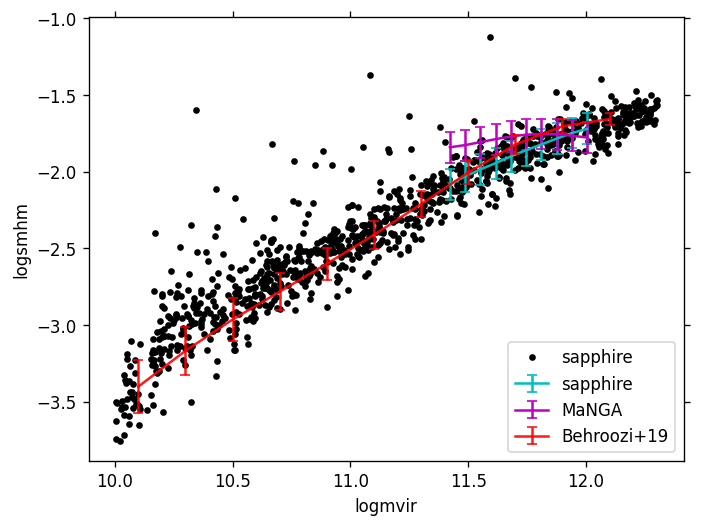

In [14]:
props = gkr.extract_quantities(sol)
z0_Mvir, z0_smhm, fail_flag, Nfail, z0_Mstar, z0_fgas, z0_mzr = props

gkr_mu, gkr_std = gkr.nadaraya_watson(z0_Mvir,z0_smhm,obs_manga[0],obs_manga[1])

plt.plot(z0_Mvir,z0_smhm,'k.',label='sapphire')
plt.errorbar(obs_manga[0],gkr_mu,yerr=jnp.sqrt(gkr_std**2+0.1**2),fmt='c-',capsize=3,label='sapphire')

plt.errorbar(obs_manga[0],obs_manga[2],yerr=obs_manga[3],fmt='m-',capsize=3,label='MaNGA')

# orig_xlim, orig_ylim = ax_smhm.get_xlim(), ax_smhm.get_ylim() 
plt.errorbar(obs_lit[0],obs_lit[2],yerr=obs_lit[3],fmt='-',color='r',capsize=3,zorder=np.inf,label='Behroozi+19',alpha=0.9)
# ax_smhm.set_xlim(orig_xlim)
# ax_smhm.set_ylim(orig_ylim)

plt.legend()

plt.xlabel('logmvir')
plt.ylabel('logsmhm')

Text(0, 0.5, '$\\log Z_*/Z_{\\odot}$ (z=0)')

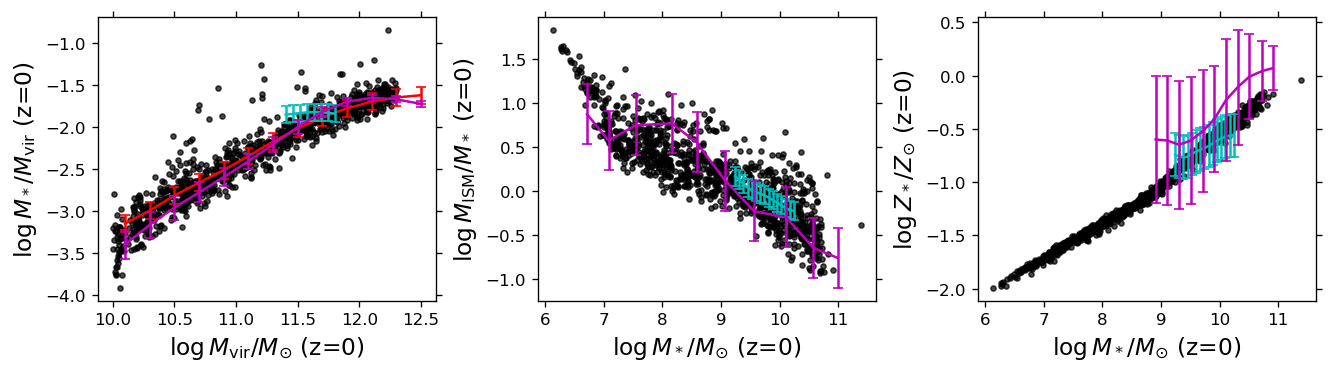

In [34]:
fig, axes = plt.subplots(nrows=1,ncols=3,figsize=(11,3),constrained_layout=True)
ax_smhm, ax_fgas, ax_mzr = axes

##### first the data/constraints
ax_smhm.errorbar(obs_manga[0],obs_manga[2],yerr=obs_manga[3],fmt='-',color='c',capsize=3,zorder=np.inf)
ax_smhm.errorbar(obs_lit[0],obs_lit[2],yerr=obs_lit[3],fmt='-',color='m',capsize=3,zorder=np.inf)
ax_smhm.plot(z0_Mvir,z0_smhm,'k.',label='sapphire',alpha=0.7)

gkr_mu_smhm, gkr_std_smhm = gkr.nadaraya_watson(z0_Mvir,z0_smhm,obs_mix[0],obs_mix[1])
ax_smhm.errorbar(obs_mix[0],gkr_mu_smhm,yerr=jnp.sqrt(gkr_std_smhm**2+0.1**2),fmt='r-',capsize=3,label='sapphire')
    
# axes[0].set_xscale('log')
ax_smhm.set_xlabel(r'$\log M_{\rm vir}/M_{\odot}$ (z=0)',fontsize=14)
ax_smhm.set_ylabel(r'$\log M_*/M_{\rm vir}$ (z=0)',fontsize=14)

ax_fgas.errorbar(obs_manga[4],obs_manga[6],yerr=obs_manga[7],fmt='-',capsize=3,zorder=np.inf,color='c',label='data')
ax_fgas.errorbar(obs_lit[4],obs_lit[6],yerr=obs_lit[7],fmt='-',capsize=3,zorder=np.inf,color='m',label='data')
ax_fgas.plot(z0_Mstar,z0_fgas,'k.',label='sapphire',alpha=0.7)

# plt.xscale('log')
ax_fgas.set_xlabel(r'$\log M_*/M_{\odot}$ (z=0)',fontsize=14)
ax_fgas.set_ylabel(r'$\log M_{\rm ISM}/M_*$ (z=0)',fontsize=14)

ax_mzr.errorbar(obs_manga[8],obs_manga[10],yerr=obs_manga[11],fmt='-',capsize=3,zorder=np.inf,color='c')
ax_mzr.errorbar(obs_lit[8],obs_lit[10],yerr=obs_lit[11],fmt='-',capsize=3,zorder=np.inf,color='m')
ax_mzr.plot(z0_Mstar,z0_mzr,'k.',label='sapphire',alpha=0.7)

ax_mzr.set_xlabel(r'$\log M_*/M_{\odot}$ (z=0)',fontsize=14)
ax_mzr.set_ylabel(r'$\log Z_*/Z_{\odot}$ (z=0)',fontsize=14)

In [40]:
config = {'obs_path':'/mnt/ceph/users/vpandya/sapphire/data/obs/'}

tum = Table.read(os.path.join(config['obs_path'],'literature/smhm_a1.002312.dat'),format='ascii')

tum = tum[(tum['HM(0)']>=10.0) & (tum['HM(0)']<=12.1)]    

tum

HM(0),Med_All(1),Err+(2),Err-(3),Med_Cen(4),Err+(5),Err-(6),Med_Cen_SF(7),Err+(8),Err-(9),Med_Cen_Q(10),Err+(11),Err-(12),Med_Sat(13),Err+(14),Err-(15),Med_SF(16),Err+(17),Err-(18),Med_Q(19),Err+(20),Err-(21),True_Med_All(22),Err+(23),Err-(24),True_Cen(25),Err+(26),Err-(27),True_Cen_SF(28),Err+(29),Err-(30),True_Cen_Q(31),Err+(32),Err-(33),True_Sat(34),Err+(35),Err-(36),True_SF(37),Err+(38),Err-(39),True_Q(40),Err+(41),Err-(42)
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
10.1,-3.374289,0.04297,0.170815,-3.401626,0.043973,0.173078,-3.402734,0.044818,0.171419,-3.223874,0.167977,0.132328,-3.208457,0.044869,0.147945,-3.376028,0.043244,0.169588,-3.165777,0.186321,0.132243,-3.379339,0.036633,0.208364,-3.40636,0.034574,0.212059,-3.407479,0.035323,0.212327,-3.232202,0.172403,0.148271,-3.213817,0.039357,0.189278,-3.381106,0.03692,0.210836,-3.173654,0.199376,0.131137
10.3,-3.13622,0.023013,0.152712,-3.167731,0.021709,0.156777,-3.169031,0.021883,0.155809,-3.038357,0.108789,0.110581,-2.9861,0.021593,0.13448,-3.13876,0.022353,0.153695,-2.96474,0.18757,0.111049,-3.141433,0.018872,0.193938,-3.172791,0.016476,0.200985,-3.174077,0.01675,0.19977,-3.045682,0.112787,0.144055,-2.991092,0.020428,0.179039,-3.143972,0.020244,0.192003,-2.972538,0.185967,0.103469
10.5,-2.930211,0.0,0.136239,-2.964034,-0.002026,0.141237,-2.965317,-0.001994,0.14101,-2.881353,0.09183,0.092084,-2.785308,0.001656,0.114646,-2.933907,0.0,0.135299,-2.775238,0.211621,0.101775,-2.934972,0.007893,0.18074,-2.968697,0.007662,0.188677,-2.969951,0.008138,0.189019,-2.890918,0.089573,0.118542,-2.790143,0.013724,0.158838,-2.938714,0.007076,0.182201,-2.780872,0.221182,0.093885
10.7,-2.740482,-0.014568,0.110318,-2.782,-0.017277,0.119456,-2.783359,-0.016172,0.119637,-2.72226,0.084219,0.08736,-2.577202,-0.003634,0.082211,-2.746782,-0.015158,0.110933,-2.580641,0.173739,0.074911,-2.745738,0.001528,0.160136,-2.787058,0.00129,0.173833,-2.788343,0.000441,0.174017,-2.731781,0.084216,0.109045,-2.58215,0.008515,0.135298,-2.751981,0.002294,0.163834,-2.587359,0.170833,0.082765
10.9,-2.547818,-0.016654,0.087788,-2.600154,-0.022625,0.104838,-2.601339,-0.023399,0.104963,-2.563603,0.062664,0.069959,-2.374736,-0.002317,0.06275,-2.556839,-0.015781,0.092476,-2.413911,0.108239,0.061362,-2.553756,0.004581,0.145532,-2.604921,0.0,0.16563,-2.606167,-0.000257,0.166548,-2.569822,0.070341,0.105021,-2.379289,0.017961,0.123205,-2.562726,0.00185,0.148489,-2.419843,0.109829,0.072567
11.1,-2.359215,-0.016454,0.077139,-2.411489,-0.022251,0.091368,-2.412814,-0.02281,0.091789,-2.389235,0.047047,0.051067,-2.202583,-0.004511,0.064251,-2.369972,-0.019325,0.081185,-2.255583,0.078909,0.04752,-2.364676,0.01624,0.143108,-2.416704,0.008446,0.158575,-2.418017,0.008158,0.15895,-2.393836,0.064923,0.094979,-2.208204,0.019354,0.128918,-2.375455,0.012172,0.145066,-2.262843,0.083295,0.073553
11.3,-2.162537,-0.009,0.070403,-2.21107,-0.012474,0.083703,-2.212061,-0.01291,0.086461,-2.200317,0.031838,0.043107,-2.015207,-0.002218,0.060488,-2.174855,-0.012527,0.076394,-2.083537,0.057466,0.029125,-2.16806,0.023879,0.132847,-2.215605,0.018628,0.149548,-2.216383,0.015261,0.151978,-2.20626,0.044162,0.100746,-2.020394,0.024236,0.12653,-2.180113,0.019599,0.140126,-2.088178,0.069639,0.082476
11.5,-1.958506,-0.002649,0.060672,-2.00395,-0.003474,0.074054,-2.005622,-0.003685,0.078556,-1.993713,0.027965,0.039741,-1.820629,0.0,0.05661,-1.973225,-0.004201,0.072021,-1.897685,0.038302,0.025077,-1.963827,0.029177,0.124058,-2.009082,0.025588,0.136282,-2.01048,0.025552,0.139515,-2.000796,0.039832,0.106282,-1.824956,0.023172,0.123739,-1.978193,0.025296,0.1308,-1.904091,0.052083,0.08472
11.7,-1.784507,0.000216,0.046219,-1.822329,-0.000243,0.05737,-1.823466,-0.002959,0.0

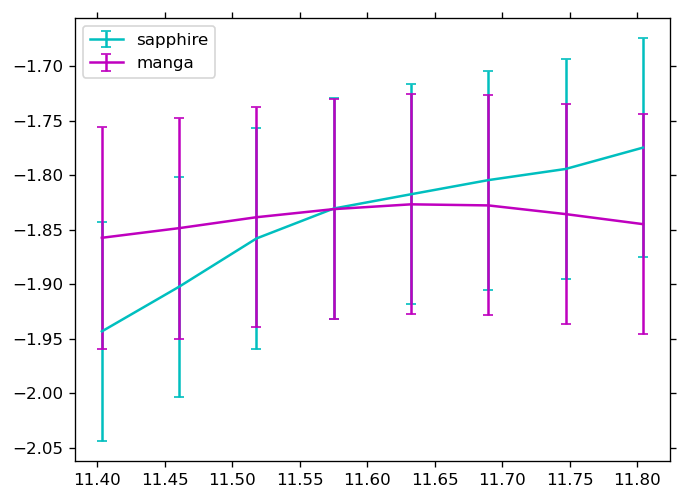

In [32]:
plt.errorbar(obs_manga[0],gkr_mu,yerr=jnp.sqrt(gkr_std**2+0.1**2),fmt='c-',capsize=3,label='sapphire')
plt.errorbar(obs_manga[0],obs_manga[2],yerr=obs_manga[3],fmt='m-',capsize=3,label='manga')
plt.legend()

In [27]:
obs_manga[0], obs_manga[1]

(Array([11.4033033 , 11.46055622, 11.51780913, 11.57506204, 11.63231496,
        11.68956787, 11.74682078, 11.8040737 ], dtype=float64),
 0.057252913419521434)

In [29]:
z0_Mstar.shape, z0_Mstar[z0_Mstar<9.0].shape, z0_Mstar[(z0_Mstar>9.0) & (z0_Mstar<10.2)].shape

((1000,), (479,), (354,))

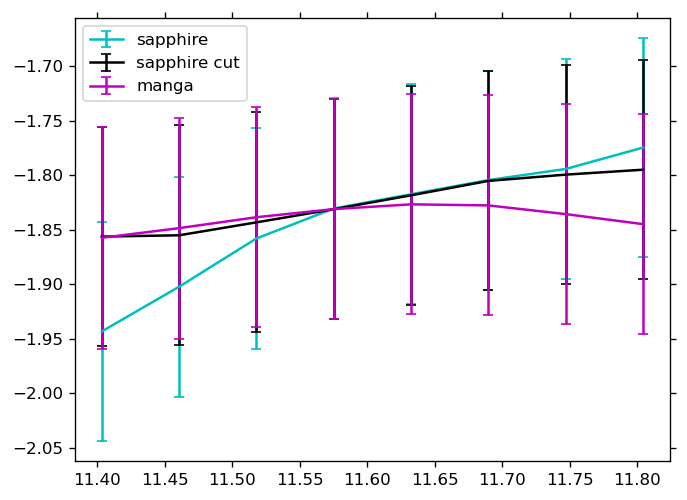

In [39]:
ind_sel = (z0_Mstar>9.5) & (z0_Mstar<10.2)
gkr_mu2, gkr_std2 = gkr.nadaraya_watson(z0_Mvir[ind_sel],z0_smhm[ind_sel],obs_manga[0],obs_manga[1])

plt.errorbar(obs_manga[0],gkr_mu,yerr=jnp.sqrt(gkr_std**2+0.1**2),fmt='c-',capsize=3,label='sapphire')
plt.errorbar(obs_manga[0],gkr_mu2,yerr=jnp.sqrt(gkr_std2**2+0.1**2),fmt='k-',capsize=3,label='sapphire cut')
plt.errorbar(obs_manga[0],obs_manga[2],yerr=obs_manga[3],fmt='m-',capsize=3,label='manga')

plt.legend()